# Surrogate Factory — UCHardLanding
## Chapter 9. Model Validation
Objectives:
- **9.0** Validate train/test split quality.
- **9.1** Predict on test set.
- **9.2** Compute metrics (R², MAE, quantile90).
- **9.2b** KS distribution tests: train vs test residuals.
- **9.3** Validate against requirements from SF_1.
- **9.4** Generate scatter and ratio plots.
- **9.5** Validation report (HTML).

### 0. Workflow initialisation

In [1]:
import sys
from pathlib import Path
repo_root = str(Path('..').resolve().parent)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from IPython.display import display, HTML, JSON
from surrogate_factory.workflow import Workflow

workflow = Workflow('pipeline_config.yaml')
workflow.resume()

2026-08-07 11:37:35 - SurrogateFactoryLogs - INFO - Initializing Workflow...


2026-08-07 11:37:35 - SurrogateFactoryLogs - INFO - Setting up Workflow folders and paths...


2026-08-07 11:37:35 - SurrogateFactoryLogs - INFO - Changing working directory to Data folder: /Users/martaarnabatmartin/Desktop/Pipelines/UCHardLanding/pipeline/data


2026-08-07 11:37:35 - SurrogateFactoryLogs - INFO - Loading default metadata schema...


2026-08-07 11:37:35 - SurrogateFactoryLogs - INFO - Tracker requested: 'mlflow'


...

Setting tracking uri: file:///Users/martaarnabatmartin/Desktop/Pipelines/UCHardLanding/pipeline/mlruns
2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Adding methods to Catalog from configuration.


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Workflow initialization completed successfully.


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Resuming workflow job: 'UCHARDLANDING_1'


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Workflow data loaded successfully.


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Workflow metadata successfully loaded for resume.


### 9. Model Validation

In [2]:
workflow.import_metadata(stage_name='SF_9_Model_Validation')

2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Importing metadata for stage: 'SF_9_Model_Validation'


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Updating metadata for stage 'Model_Validation' in memory.


In [3]:
job = workflow.config['job_name']
Train_set = workflow.load_data(job + '_Train_set.csv')
Val_set   = workflow.load_data(job + '_Val_set.csv')
Test_set  = workflow.load_data(job + '_Test_set.csv')
print(f'Train set : {Train_set.shape}')
print(f'Val set   : {Val_set.shape}')
print(f'Test set  : {Test_set.shape}')

2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCHardLanding/pipeline/data/UCHARDLANDING_1_Train_set.csv' (Format: csv)


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (62549, 9)


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCHardLanding/pipeline/data/UCHARDLANDING_1_Val_set.csv' (Format: csv)


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (8936, 9)


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Loading data from '/Users/martaarnabatmartin/Desktop/Pipelines/UCHardLanding/pipeline/data/UCHARDLANDING_1_Test_set.csv' (Format: csv)


2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - Successfully loaded data shape: (17872, 9)


Train set : (62549, 9)
Val set   : (8936, 9)
Test set  : (17872, 9)


#### 9.0 Split Validation

In [4]:
from model_validation.split_val import split_validation
split_result = split_validation(workflow, Train_set, Test_set)

2026-08-07 11:37:36 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'split_validation'


  [split_val] Subsampled train: 3000/62549 rows
  [split_val] Subsampled test : 3000/17872 rows



  Metric                       Value    Status  (threshold)
  ----------------------------------------------------------
  Residual voxel proportion  :  0.000   ✓   (≤ 0.05)
  Valid test proportion      :  0.966
  Phacking test proportion   :  0.005
  Isolated test proportion   :  0.029
  Isolated train proportion  :  0.000


#### 9.1 Predictions

In [5]:
from model_validation.prediction import predict
model_output = predict(workflow, Test_set)
train_output = predict(workflow, Train_set)
val_output   = predict(workflow, Val_set)
model_output.head()

2026-08-07 11:50:15 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'


2026-08-07 11:50:16 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'


2026-08-07 11:50:16 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'predict'


,GradientBoosting__O1,GradientBoosting__O2,MLP__O1,MLP__O2
0,0.413309,0.240301,0.414846,0.247569
1,0.628523,0.460602,0.624102,0.451878
2,0.330466,0.280567,0.326768,0.262512
3,0.256602,0.194538,0.259436,0.203955
4,0.511980,0.290863,0.514449,0.282799


#### 9.2 Metrics

In [6]:
from model_validation.score import calculate_metrics
metrics = calculate_metrics(workflow, Test_set, model_output)
JSON(metrics)

2026-08-07 11:50:16 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'calculate_metrics'



Output                      R² GradientBoosting        R² MLP
--------------------------------------------------------
O1                                  0.9960        0.9952
O2                                  0.9712        0.9705

Best model per output (by R²):
  O1                           → GradientBoosting  (R²=0.9960)
  O2                           → GradientBoosting  (R²=0.9712)


<IPython.core.display.JSON object>

#### 9.2b Distribution Tests (KS: train vs test residuals)

In [7]:
from model_validation.score import distribution_tests
ks_results = distribution_tests(workflow, Train_set, Test_set, train_output, model_output)

2026-08-07 11:50:16 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'distribution_tests'



  KS test p-values — GradientBoosting  (H₀: train and test residuals same distribution)
  Output                           p-value      status
  ----------------------------------------------------
  O1                                0.0742           ✓
  O2                                0.1623           ✓

  KS test p-values — MLP  (H₀: train and test residuals same distribution)
  Output                           p-value      status
  ----------------------------------------------------
  O1                                0.7086           ✓
  O2                                0.8057           ✓


#### 9.3 Validation against requirements

In [8]:
from model_validation.validation import validate
validate(workflow, metrics)

2026-08-07 11:50:16 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'validate'



  Output                      Metric          Target      GradientBoosting           MLP
  ------------------------------------------------------------------------------------
  O1                          quantile90      0.1000      ✓     0.0407✓     0.0443
  O2                          quantile90      0.1000      ✓     0.0870✓     0.0851


#### 9.3b Validation Summary — Table

In [9]:
import ipywidgets as widgets
import pandas as pd
from IPython.display import display

validation_results = workflow.metadata.get_step_data(['metadata', 'Model_Validation', 'validation_results'])
models_info_w = workflow.metadata.get_step_data(['metadata', 'Model_Training', 'Models'])
labels_w = [m['label'] for m in models_info_w]

rows = []
for vr in validation_results:
    row = {'Output': vr['output'], 'Metric': vr['metric'], 'Target': f"< {vr['target']}"}
    for lbl in labels_w:
        m = vr['models'].get(lbl, {})
        score, passed = m.get('score'), m.get('passed')
        row[lbl] = (f"{'✅' if passed else '❌'} {score:.4f}") if score is not None else '?'
    rows.append(row)

df_val = pd.DataFrame(rows).set_index('Output')

def color_cell(val):
    if '✅' in str(val): return 'background-color:#d4edda; color:#155724'
    if '❌' in str(val): return 'background-color:#f8d7da; color:#721c24'
    return ''

styled = df_val.style.applymap(color_cell, subset=labels_w).set_caption('Validation Results')
display(styled)

/var/folders/p1/nzt7bhk56jn6tj9cf8sbh8ym0000gn/T/ipykernel_26140/3740910048.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df_val.style.applymap(color_cell, subset=labels_w).set_caption('Validation Results')


,Metric,Target,GradientBoosting,MLP
Output,,,,
O1,quantile90,< 0.1,✅ 0.0407,✅ 0.0443
O2,quantile90,< 0.1,✅ 0.0870,✅ 0.0851


#### 9.4 Plots

2026-08-07 11:50:17 - SurrogateFactoryLogs - INFO - ▶ Executing Workflow Step: 'plot'


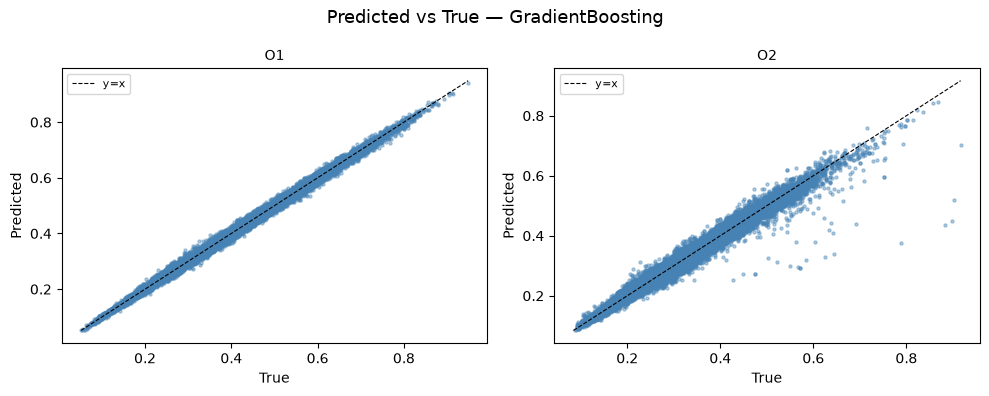

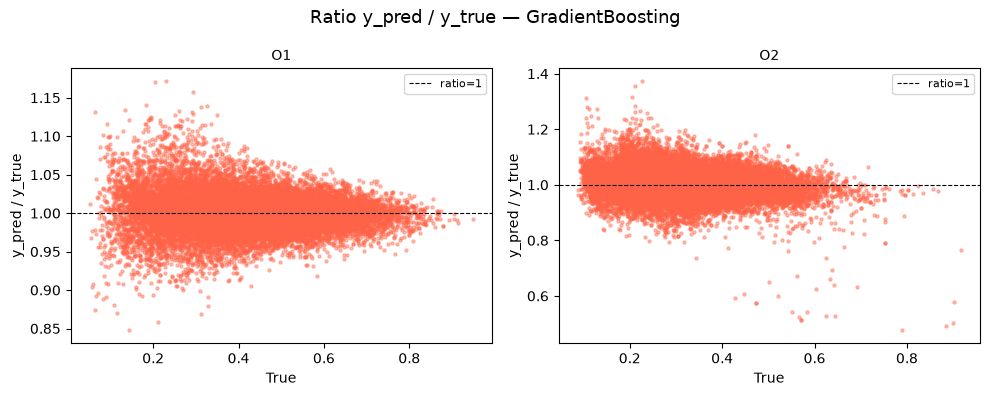

[GradientBoosting] scatter → scatter_GradientBoosting.png   ratio → ratio_GradientBoosting.png


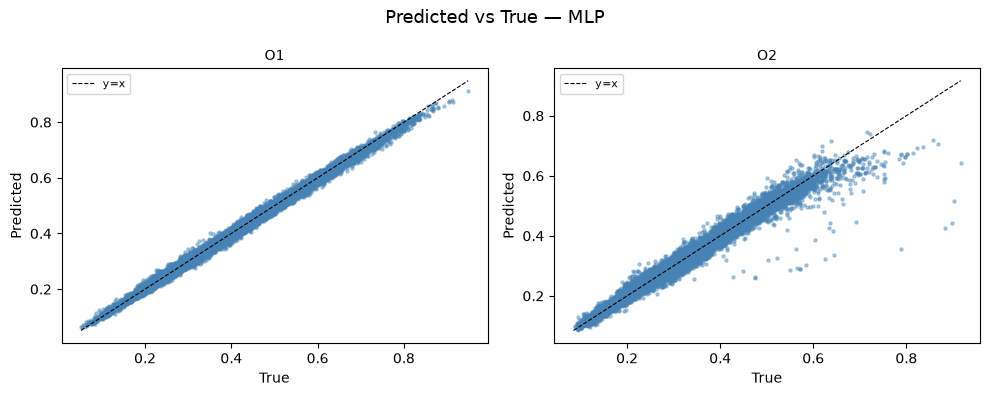

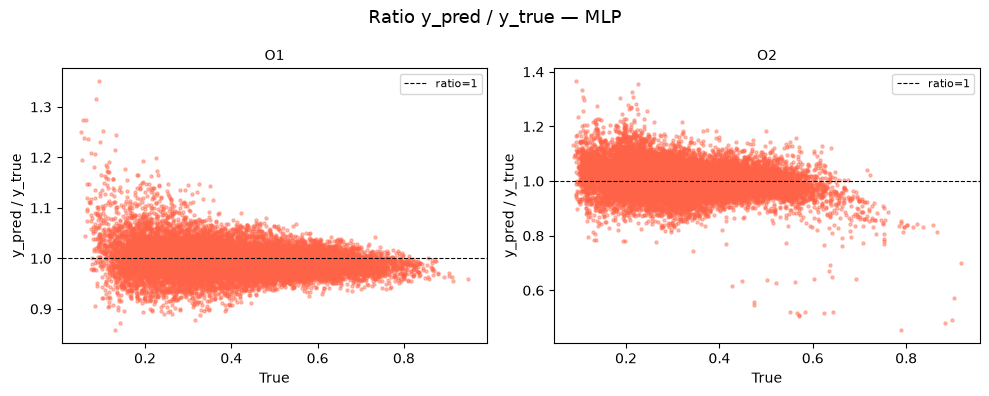

[MLP] scatter → scatter_MLP.png   ratio → ratio_MLP.png


In [10]:
%matplotlib inline
from model_validation.visualize import plot
plot(workflow, Test_set, model_output)

#### 9.5 Validation Report

In [ ]:
import os, sys, subprocess
from pathlib import Path
from model_validation.export_validation_csvs import export_validation_csvs

csv_dirs = export_validation_csvs(
    workflow,
    Train_set, Val_set, Test_set,
    train_output, val_output, model_output,
)

script_path = Path(workflow.config["data.folder"]).parent / "python_nodes_library" / "model_validation" / "validation_script.py"
output_dir  = Path(workflow.config["artifacts.folder"]) / "validation_reports"
output_dir.mkdir(parents=True, exist_ok=True)

ms_w = workflow.metadata.get_step_data(["metadata", "Model_Selection"])
num_inputs_w = Train_set[ms_w["inputs"]].select_dtypes(include="number").columns.tolist()

# Repo root = .../<repo>/<UseCase>/pipeline/python_nodes_library/model_validation -> up 4.
# Derived, never hardcoded, so the notebook runs on any machine.
repo_root = script_path.parents[4]
env = {
    **os.environ,
    "PYTHONPATH": str(repo_root / "src") + os.pathsep + os.environ.get("PYTHONPATH", ""),
    "MLFLOW_ALLOW_FILE_STORE": "true",
}

# The report template runs voxel tesselation + convex-hull membership, which is
# O(n^2) in the number of unique input combinations. Above a few thousand rows
# it never finishes, so cap the sample the template works on.
subsample = 300 if len(Train_set) > 5000 else None
print(f"Train rows: {len(Train_set):,} -> subsample_size = {subsample or 'full set'}")

for label, csv_dir in csv_dirs.items():
    print(f"Running validation report for {label}...")
    cmd = [
        sys.executable, str(script_path),
        "-d", str(csv_dir), "-n", label, "-o", str(output_dir),
        "--exclude_warnings",
    ]
    if subsample:
        cmd += ["--subsample_size", str(subsample)]
    cmd += ["--splitting_variables", *num_inputs_w]

    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=1800, env=env)
        if result.returncode == 0:
            print(f"  OK  {output_dir / (label + '_validation_output.html')}")
        else:
            print(f"  FAILED\n{result.stderr[-2000:]}")
    except subprocess.TimeoutExpired:
        print(f"  TIMEOUT (>1800s) for {label} - lower subsample further.")


### Save

In [ ]:
workflow.save_metadata()

#### 9.7 Executive Summary Report (PDF + HTML)

Generates the mandatory multi-part validation report via
`reporting/generate_executive_summary.py`:

- **Part 1 — Executive Summary** (winner model, <= 2 pages)
- **Part 2 — Technical Review** (all models: TOC, scatter/ratio, KS, split, roadmap)
- **Part 3 — Deep Analysis** (winner model: data overview, train-test split,
  error quantification, P(E|X), P(E|Y), uncertainty)

Output lands in `data/artifacts/validation_reports/`.

> Requires **tectonic** (LaTeX engine) on PATH.
> macOS: `brew install tectonic` — Linux: `conda install -c conda-forge tectonic`


In [ ]:
import os, sys, shutil, subprocess
from pathlib import Path

pipeline_dir  = Path(workflow.config["data.folder"]).parent
artifacts_dir = Path(workflow.config["artifacts.folder"])
job           = workflow.config["job_name"]

report_script = pipeline_dir / "python_nodes_library" / "reporting" / "generate_executive_summary.py"
meta_json     = artifacts_dir / f"metadata_{job}.json"
report_dir    = artifacts_dir / "validation_reports"
report_dir.mkdir(parents=True, exist_ok=True)

# Repo root = .../<repo>/<UseCase>/pipeline -> up 2. Keeps this portable across machines.
repo_root = pipeline_dir.parent.parent
env = {
    **os.environ,
    "PYTHONPATH": str(repo_root / "src") + os.pathsep + os.environ.get("PYTHONPATH", ""),
    "MLFLOW_ALLOW_FILE_STORE": "true",
}

if not report_script.exists():
    print(f"Report script not found: {report_script}")
elif not meta_json.exists():
    print(f"Metadata not found: {meta_json}\n   Run the 'Save' cell above first.")
elif shutil.which("tectonic") is None:
    print("tectonic (LaTeX engine) not found on PATH - the PDF cannot be built.")
    print("   macOS : brew install tectonic")
    print("   Linux : conda install -c conda-forge tectonic")
else:
    try:
        result = subprocess.run(
            [sys.executable, str(report_script), str(meta_json), "--output", str(report_dir)],
            capture_output=True, text=True, timeout=1800, env=env,
        )
        if result.stdout:
            print(result.stdout[-3000:])
        if result.returncode == 0:
            for f in sorted(report_dir.glob("executive_summary_*")):
                print(f"  OK  {f.name}  ({f.stat().st_size/1024:.0f} KB)")
        else:
            print("Report generation failed:")
            print(result.stderr[-3000:])
    except subprocess.TimeoutExpired:
        print("Timeout (>1800s) building the executive summary report.")
